# Template Based Diagram Layouts
This notebook is intended to explore the use of template-based diagram layouts 
for visualizing relationships between structures in a dataset. 
The goal is to compare this approach with the current optimization-based layout 
and also to evaluate the use to Networkx for layouts.

## Setup

### Imports

In [20]:
from typing import Dict, List, Union

from pathlib import Path
import re

from pprint import pprint

In [21]:
import xml.etree.ElementTree as ET
from itertools import chain


In [22]:
import pandas as pd
import xlwings as xw
import networkx as nx
from matplotlib import pyplot as plt

In [23]:
from structure_set import StructureSet
from dicom import DicomStructureFile
from structure_id_parser import parse_structure_metadata, merge_priority_columns
from diagram_rendering import (
    apply_crossing_heavy_label_offsets,
    render_template_diagram
    )

### Paths

In [24]:
base_path = Path.cwd()
dicom_path = base_path / "tests"
structure_filter_def = base_path / "src" / "webapp" / "config" / "structure_filter_rules.json"

## Utility Functions

### Load the DICOM file

In [25]:
def load_structures(dicom_file: DicomStructureFile,
                    apply_filter=False)->pd.DataFrame:
    '''
    Load structure names from a DICOM file and optionally apply a filter.

    Args:
        dicom_file (DicomStructureFile): The DICOM structure file.
        apply_filter (bool): Whether to apply a filter to the structures.
            Default is False.

    Returns:
        pd.DataFrame: A DataFrame containing the structure IDs and their metadata.
    '''
    # get structure IDs
    meta_data = dicom_file.get_structure_filter_metadata()
    if apply_filter:
        filter_report = dicom_file.evaluate_structure_filters(structure_filter_def)
        selection = filter_report.SelectedByDefault & filter_report.DisplayedByDefault
        meta_data = meta_data[selection]
    return meta_data

In [26]:
def create_structure_groups(structures_df: pd.DataFrame) -> pd.DataFrame:
    """
    Create horizontal and vertical grouping columns in the structures DataFrame.

    Args:
        structures_df (pd.DataFrame): The DataFrame containing structure metadata.
    Returns:
        pd.DataFrame: The updated DataFrame with 'h_grouping' and 'v_grouping' columns.
    """
    horizontal_group_columns = ['TargetNumber', 'TargetDose', 'Classifier',
                                'Combined', 'TargetOrgan']
    horizontal_columns_to_merge = [col for col in horizontal_group_columns
                                if col in structures_df.columns]

    vertical_group_columns = ['Mod', 'DICOM Type', 'TargetType',
                            'ExpansionSize', 'Structure Code']
    vertical_columns_to_merge = [col for col in vertical_group_columns
                                if col in structures_df.columns]

    structures_df['h_grouping'] = merge_priority_columns(structures_df,
                                                        horizontal_columns_to_merge)
    structures_df['v_grouping'] = merge_priority_columns(structures_df,
                                                        vertical_columns_to_merge)

    structures_df.sort_values(by=['h_grouping', 'v_grouping'], inplace=True)
    return structures_df


## Load an example CNS DICOM structure set

### Path to the example DICOM file

In [27]:
dcm_file_name = 'RS.CNS_FSRT_2_GTV.BRAI.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)


INFO:dicom:Successfully loaded DICOM dataset from RS.CNS_FSRT_2_GTV.BRAI.dcm


INFO:dicom:Extracted 2911 contours from 35 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.040 cm/pixel


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.CNS_FSRT_2_GTV.BRAI.dcm"),
 'PatientID': 'CNS_FSRT_2_GTV',
 'PatientLastName': 'CNS_FSRT_2_GTV_Partition_Error',
 'PatientName': 'CNS_FSRT_2_GTV_Partition_Error',
 'SeriesDescription': '',
 'SeriesNumber': '0',
 'StructureSet': 'BRAI',
 'StudyID': ''}


In [28]:
structure_data = load_structures(dicom_file)
structures_df = parse_structure_metadata(structure_data)

### Create a grouping column from the target number, dose, classifier and organ columns

In [29]:
structures_df = create_structure_groups(structures_df)
include_structures = list(structures_df.index)
structures_df[['h_grouping', 'v_grouping']]

,h_grouping,v_grouping
Structure,,
GTV 1 xxGy,1,GTV
PTV 1_24Gyin3,1,PTV
shell_PTV 1_24Gyin3,1,shell
GTV 2 xxGy,2,GTV
PTV 2_24Gyin3,2,PTV
shell_PTV 2_24Gyin3,2,shell
GTV Total,Total,GTV
PTV Total,Total,PTV
CTV,NaN,CTV


### Determine the relationships between the structures

In [30]:
structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures)


INFO:structure_set:Building StructureSet from 2911 contour points (unit: cm)


INFO:structure_set:Skipping structure BODY (1) due to filters
INFO:structure_set:Adding structure GTV 1 xxGy (4)
INFO:structure_set:Adding structure GTV 2 xxGy (5)
INFO:structure_set:Adding structure GTV Total (9)
INFO:structure_set:Adding structure PTV 1_24Gyin3 (10)
INFO:structure_set:Adding structure PTV 2_24Gyin3 (11)
INFO:structure_set:Adding structure PTV Total (15)
INFO:structure_set:Skipping structure Avoid INNER (17) due to filters
INFO:structure_set:Skipping structure Avoid MID (18) due to filters
INFO:structure_set:Skipping structure Avoid OUTER (19) due to filters
INFO:structure_set:Skipping structure Brain (20) due to filters
INFO:structure_set:Skipping structure BrainStem (21) due to filters
INFO:structure_set:Skipping structure Cochlea L (22) due to filters
INFO:structure_set:Skipping structure Cochlea R (23) due to filters
INFO:structure_set:Skipping structure Globe L (24) due to filters
INFO:structure_set:Skipping structure Globe R (25) due to filters
INFO:structure_se

In [31]:
structure_set.summary().set_index('ROI')['Name'].to_dict()

{4: 'GTV 1 xxGy',
 5: 'GTV 2 xxGy',
 9: 'GTV Total',
 10: 'PTV 1_24Gyin3',
 11: 'PTV 2_24Gyin3',
 15: 'PTV Total',
 34: 'PTV+15',
 59: 'shell_PTV 2_24Gyin3',
 62: 'shell_PTV 1_24Gyin3'}

In [32]:
structure_set.get_relationship(34, 62).relationship_type.label

'Overlaps with'

In [33]:
def get_rt(rel): return rel.relationship_type.label
relations = structure_set.relationship_matrix.map(get_rt)

In [34]:
relations

Structure_A,PTV+15,shell_PTV 1_24Gyin3,shell_PTV 2_24Gyin3,PTV Total,PTV 1_24Gyin3,PTV 2_24Gyin3,GTV Total,GTV 1 xxGy,GTV 2 xxGy
Structure_B,,,,,,,,,
PTV+15,is Equal to,Overlaps with,Overlaps with,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by,is Enclosed by
shell_PTV 1_24Gyin3,Overlaps with,is Equal to,is Disjoint from,has an Unknown relationship with,is Confined by,is Disjoint from,is Disjoint from,is Enclosed by,is Disjoint from
shell_PTV 2_24Gyin3,Overlaps with,is Disjoint from,is Equal to,has an Unknown relationship with,is Disjoint from,is Confined by,is Disjoint from,is Disjoint from,is Enclosed by
PTV Total,Surrounds,has an Unknown relationship with,has an Unknown relationship with,is Equal to,Partitions,Partitions,is Within,is Within,is Within
PTV 1_24Gyin3,Surrounds,Confines,is Disjoint from,is Partitioned by,is Equal to,is Disjoint from,Overlaps with,is Within,is Disjoint from
PTV 2_24Gyin3,Surrounds,is Disjoint from,Confines,is Partitioned by,is Disjoint from,is Equal to,Overlaps with,is Disjoint from,is Within
GTV Total,Surrounds,is Disjoint from,is Disjoint from,Contains,Overlaps with,Overlaps with,is Equal to,Partitions,Partitions
GTV 1 xxGy,Surrounds,Surrounds,is Disjoint from,Contains,Contains,is Disjoint from,is Partitioned by,is Equal to,is Disjoint from
GTV 2 xxGy,Surrounds,is Disjoint from,Surrounds,Contains,is Disjoint from,Contains,is Partitioned by,is Disjoint from,is Equal to


## Config-driven NetworkX diagram prototype

This section builds an embedded matplotlib diagram from `structure_set` using style settings from `src/webapp/config/diagram_settings.json`.

- Node shapes come from `node_shapes.shape_map`
- Edge colors/styles come from `relationship_styles`
- Filtering matches the first-pass webapp defaults used earlier (hide `DISJOINT`, `UNKNOWN`, and logical edges)
- Layout is explicit and tunable: horizontal by `h_grouping`, vertical by `v_grouping`

## Current Layout Design Summary

This notebook currently uses a template-based deterministic layout for structure
relationship diagrams.

- Horizontal placement: grouped by `h_grouping` with ordering rule
  numeric groups first, then text groups, then `None`, blank, and missing.
- Vertical placement: grouped by `v_grouping` with preferred order
  GTV -> CTV -> PTV -> TREATED VOLUME -> SHELL.
- Duplicate handling: structures in the same vertical slot are offset with a fixed
  spread so labels remain readable.
- Styling source: node/edge appearance is loaded from
  `src/webapp/config/diagram_settings.json` for visual parity.
- Edge geometry: curved directed edges are drawn with `arc3` and labels are
  anchored from rendered shaft geometry instead of abstract node midpoints.
- Label readability pass: a second pass can move only crossing-heavy labels to
  deterministic non-midpoint positions on the same edge, including node-aware
  crossing checks.
- Layering rule: nodes are forced above edges and relation labels.

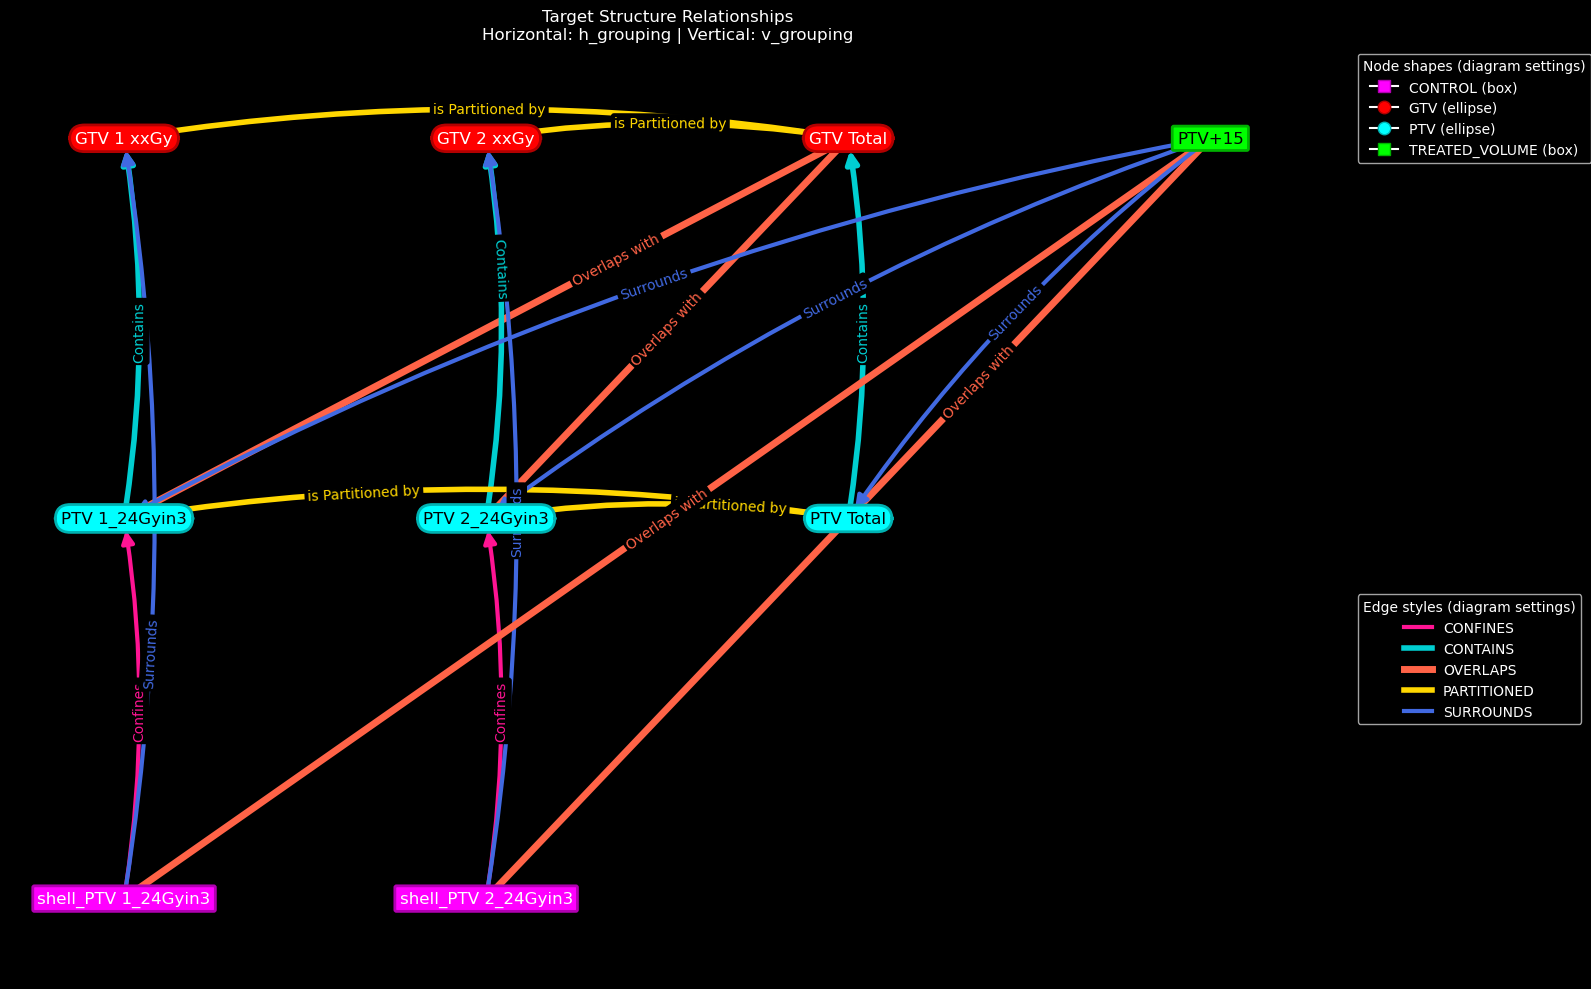

In [35]:
from IPython.display import display
from diagram_rendering import (
    apply_crossing_heavy_label_offsets,
    render_template_diagram,

)

module_result = render_template_diagram(
    structure_set=structure_set,
    structures_df=structures_df,
    diagram_settings_path=base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json',
    hide_logical_edges=True,
    show_plot=False,

)

apply_crossing_heavy_label_offsets(module_result)
#display(module_result.fig)


## Load an example H&N DICOM structure set

In [ ]:
dcm_file_name = 'RS.HN_Struct.OROP.dcm'
dcm_file_path = dicom_path / dcm_file_name
dicom_file = DicomStructureFile(top_dir=dicom_path, file_path=dcm_file_path)
pprint(dicom_file.structure_set_info)
structure_data = load_structures(dicom_file)
structures_df = parse_structure_metadata(structure_data)
structures_df = create_structure_groups(structures_df)
include_structures = list(structures_df.index)
structures_df[['h_grouping', 'v_grouping']]

structure_set = StructureSet(dicom_structure_file=dicom_file,
                             include_structures=include_structures)


INFO:dicom:Successfully loaded DICOM dataset from RS.HN_Struct.OROP.dcm
INFO:dicom:Extracted 3666 contours from 61 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.HN_Struct.OROP.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.070 cm/pixel
INFO:structure_set:Building StructureSet from 3666 contour points (unit: cm)


{'File': WindowsPath("d:/OneDrive - Queen's University/Python/Projects/StructureRelations/tests/RS.HN_Struct.OROP.dcm"),
 'PatientID': 'HN_Struct',
 'PatientLastName': 'Head',
 'PatientName': 'Head^and^Neck^Structures',
 'SeriesDescription': 'ARIA RadOnc Structure Sets',
 'SeriesNumber': '234',
 'StructureSet': 'OROP',
 'StudyID': ''}


INFO:structure_set:Skipping structure BODY (1) due to filters
INFO:structure_set:Skipping structure Avoid Post (3) due to filters
INFO:structure_set:Skipping structure Brain (4) due to filters
INFO:structure_set:Skipping structure BrainStem (5) due to filters
INFO:structure_set:Skipping structure Cochlea L (6) due to filters
INFO:structure_set:Skipping structure Cochlea R (7) due to filters
INFO:structure_set:Adding structure CTV 56 L (8)
INFO:structure_set:Adding structure CTV 56 R (9)
INFO:structure_set:Adding structure CTV 70 (12)
INFO:structure_set:Skipping structure Esophagus (13) due to filters
INFO:structure_set:Adding structure eval PTV 56 (14)
INFO:structure_set:Adding structure eval PTV 70 (16)
INFO:structure_set:Skipping structure Globe L (17) due to filters
INFO:structure_set:Skipping structure Globe R (18) due to filters
INFO:structure_set:Adding structure GTV (19)
INFO:structure_set:Adding structure GTVn (20)
INFO:structure_set:Skipping structure Larynx (22) due to filter

AttributeError: 'NoneType' object has no attribute 'relationship_type'

In [37]:

def get_rt(rel): return rel.relationship_type.label
relations = structure_set.relationship_matrix.map(get_rt)

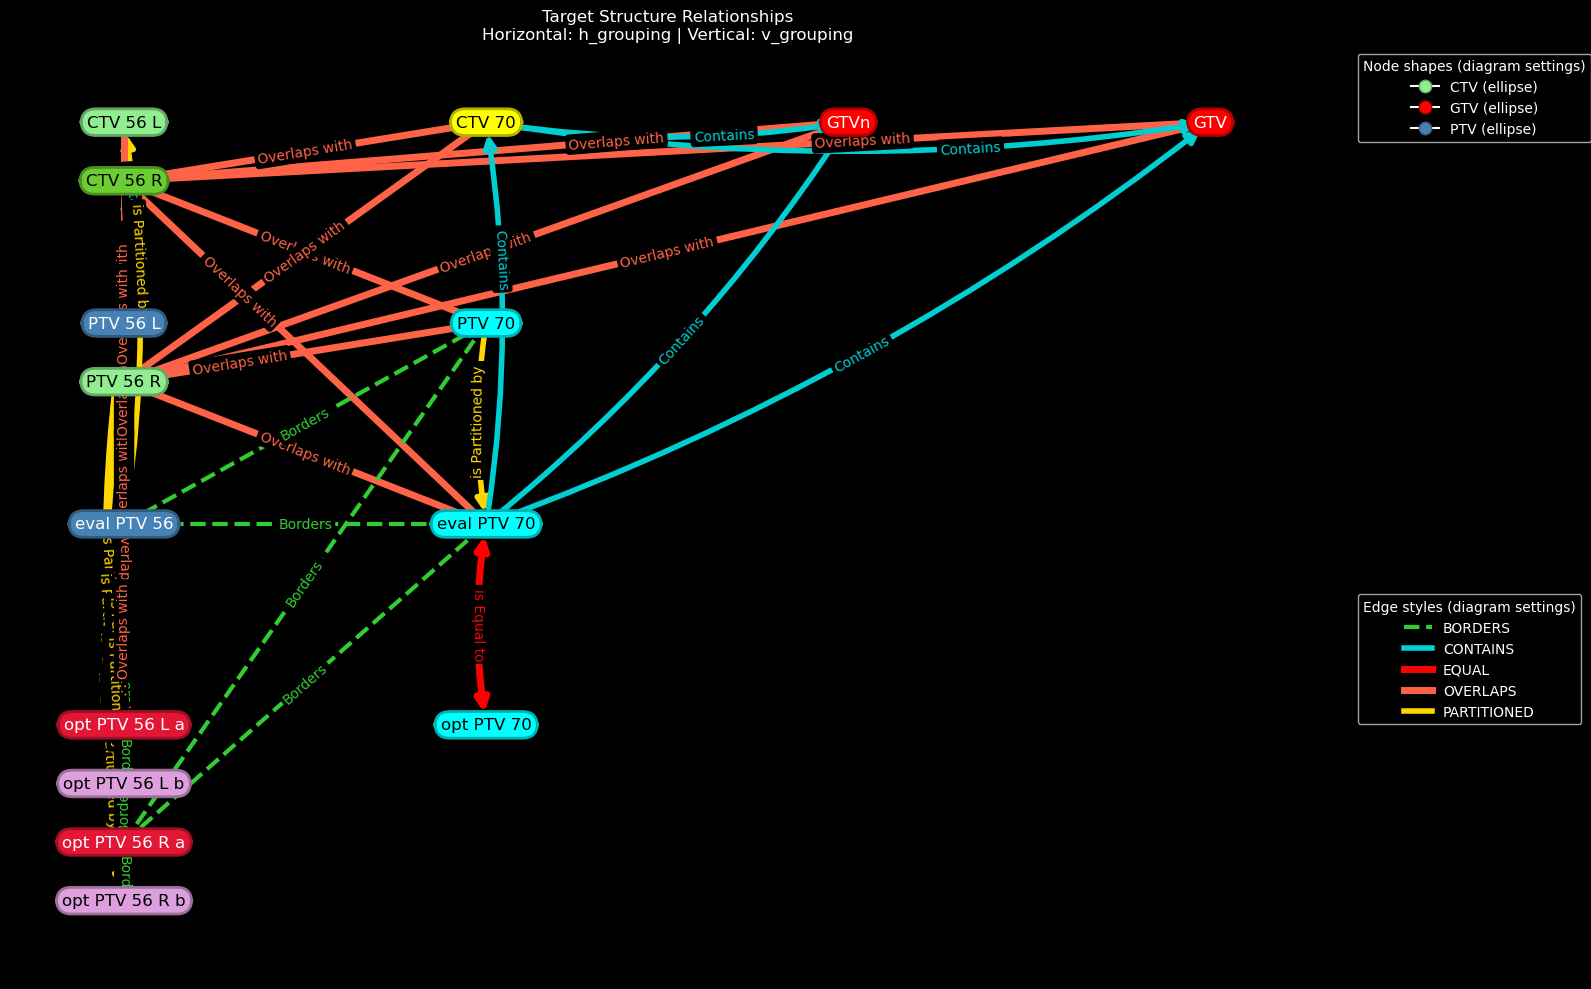

In [38]:
module_result = render_template_diagram(
    structure_set=structure_set,
    structures_df=structures_df,
    diagram_settings_path=base_path / 'src' / 'webapp' / 'config' / 'diagram_settings.json',
    hide_logical_edges=True,
    show_plot=False,

)

apply_crossing_heavy_label_offsets(module_result)
#display(module_result.fig)
